# AAL Sales Analysis (Q4 2020)
### Course-End Project: Applied Data Science with Python
**Author**: Jignesh Rana  
**Date**: July 2026  

---

## Phase 1: Project Setup & Exploratory Data Analysis (EDA)

In this phase, we:
1. **T1.1**: Import the required libraries (Pandas, NumPy, Seaborn, Matplotlib) and configure the plotting environment.
2. **T1.2**: Load the CSV data (`AusApparalSales4thQrt2020.csv`) and inspect its raw metadata (shape, column data types, memory usage, and first few rows) to get a general understanding of the dataset.

In [58]:
import sys
print(sys.executable)


/media/jignesh/Data/ihfc/IHFC-Leaning/project3 - SalesAnalysis/.venv/bin/python


In [59]:
# T1.1: Import necessary libraries and set the visualization theme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme for Seaborn and default figure size
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [60]:
# T1.2: Load the dataset and inspect its structure
csv_path = 'problem_description/AusApparalSales4thQrt2020.csv'
df = pd.read_csv(csv_path)

# Check dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Check column names, types, and non-null counts
print("\nDataset Summary Info:")
df.info()

# View first 5 rows
print("\nFirst 5 Rows of the Dataset:")
df.head()

Dataset Shape: (7560, 6)

Dataset Summary Info:
<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB

First 5 Rows of the Dataset:


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


## Phase 2: Data Wrangling & Cleaning

In this phase, we perform:
1. **T2.1**: Strip leading/trailing whitespaces from object/categorical columns (`State`, `Group`, `Time`).
2. **T2.2**: Inspect the dataset for missing data (`isna()`, `notna()`) and check for logical inconsistencies (e.g., negative values).
3. **T2.3**: Normalize numerical columns (`Sales`, `Unit`) using Min-Max Scaling.
4. **T2.4**: Discuss `GroupBy()` function application (data chunking vs. merging).

### T2.1: Text Cleaning (Trimming Whitespaces)

During our initial analysis, we noticed leading spaces in categorical columns (e.g., `' WA'` instead of `'WA'`). We must strip these spaces so that filtering and group comparisons work correctly.

In [61]:
# Inspect unique values before cleaning
print("Before cleaning:")
print("Unique States:", list(df['State'].unique()))
print("Unique Groups:", list(df['Group'].unique()))
print("Unique Times:", list(df['Time'].unique()))

# Strip leading/trailing spaces from object/string columns
for col in ['State', 'Group', 'Time']:
    df[col] = df[col].str.strip()

# Verify the unique values after cleaning
print("\nAfter cleaning:")
print("Unique States:", list(df['State'].unique()))
print("Unique Groups:", list(df['Group'].unique()))
print("Unique Times:", list(df['Time'].unique()))

Before cleaning:
Unique States: [' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS']
Unique Groups: [' Kids', ' Men', ' Women', ' Seniors']
Unique Times: [' Morning', ' Afternoon', ' Evening']

After cleaning:
Unique States: ['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
Unique Groups: ['Kids', 'Men', 'Women', 'Seniors']
Unique Times: ['Morning', 'Afternoon', 'Evening']


### T2.2: Missing & Incorrect Data Detection

We check for missing/null values using `isna()` and check for any negative values in `Sales` or `Unit` to ensure data integrity.

In [62]:
# Check for missing values in all columns
print("Missing values check (isna()):")
print(df.isna().sum())

# Verify completeness using notna()
print("\nComplete records count (notna()):")
print(df.notna().sum())

# Check for logical errors (negative values in Sales or Unit)
negative_sales = (df['Sales'] < 0).sum()
negative_units = (df['Unit'] < 0).sum()
print(f"\nLogical Consistency Checks:")
print(f"Rows with negative sales: {negative_sales}")
print(f"Rows with negative units: {negative_units}")

# Recommendation:
# Since there are zero missing or negative values, no imputation (fillna) or dropping (dropna) is required.
# If missing values were present, we would recommend:
# 1. Filling numerical nulls with the median (robust to outliers).
# 2. Filling categorical nulls with the mode (most common value).
# 3. Dropping rows only if missing entries are completely random and represent < 2% of the dataset.

Missing values check (isna()):
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Complete records count (notna()):
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

Logical Consistency Checks:
Rows with negative sales: 0
Rows with negative units: 0


### T2.3: Feature Normalization (Min-Max Scaling)

We normalize the numerical columns `Sales` and `Unit` using Min-Max Scaling to scale them to a range of $[0, 1]$.

$$
x_{\text{scaled}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$

**Why Normalization?** It bounds variables to $[0, 1]$, making comparisons easier and preserving relative differences. This is preferred over Standardization (Z-score) because our sales data does not follow a bell-curve (normal distribution).

In [63]:
# Define min-max scaling function
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Apply normalization
df['Sales_Normalized'] = min_max_normalize(df['Sales'])
df['Unit_Normalized'] = min_max_normalize(df['Unit'])

# Display the first few rows with original and normalized values
df[['Sales', 'Sales_Normalized', 'Unit', 'Unit_Normalized']].head(10)

,Sales,Sales_Normalized,Unit,Unit_Normalized
0,20000,0.095238,8,0.095238
1,20000,0.095238,8,0.095238
2,10000,0.031746,4,0.031746
3,37500,0.206349,15,0.206349
4,7500,0.015873,3,0.015873
5,25000,0.126984,10,0.126984
6,7500,0.015873,3,0.015873
7,27500,0.142857,11,0.142857
8,37500,0.206349,15,0.206349
9,37500,0.206349,15,0.206349


### T2.4: GroupBy Function Application (Chunking vs. Merging)

**Concept**:
*   **Data Chunking (Split-Apply-Combine)**: In Pandas, `groupby()` splits a large dataset into smaller groups (chunks), applies an aggregation function (like `sum` or `mean`), and combines them back. This is memory-efficient and ideal for our reporting needs.
*   **Data Merging**: Combines two tables based on a common key (like SQL JOIN). Useful when merging our aggregated results back into a larger table.

**Recommendation**: We choose **Data Chunking** because we need to calculate total sales by demographic groups and states separately without joining external datasets.

## Phase 3: Data Analysis & Descriptive Statistics

In this phase, we perform:
1. **T3.1**: Compute descriptive statistics (mean, median, mode, and standard deviation) for `Sales` and `Unit` columns.
2. **T3.2**: Identify the demographic groups generating the highest and lowest sales.

### T3.1: Descriptive Statistical Analysis

We calculate the central tendency (Mean, Median, Mode) and dispersion (Standard Deviation) for both `Sales` and `Unit` columns.
*   **Mean**: Average value. (Sensitive to outliers).
*   **Median**: Middle value when sorted. (Robust against outliers, represents a 'typical' order size).
*   **Mode**: Most frequent value. (Popular purchase size).
*   **Standard Deviation**: Volatility/spread around the mean.

In [ ]:
print("\n mean of Sales :",df['Sales'].mean())
print("\n median of Sales :",df['Sales'].median())
print("\n mode of Sales :",df['Sales'].mode())
print("\n std of Sales :",df['Sales'].std())

print("\n mean of Unit :",df['Unit'].mean())
print("\n median of Unit :",df['Unit'].median())
print("\n mode of Unit :",df['Unit'].mode())
print("\n std of Unit :",df['Unit'].std())






 mode of Sales : 0    22500
Name: Sales, dtype: int64


In [65]:
# Calculate descriptive statistics using Pandas
stats_df = pd.DataFrame(index=['Mean', 'Median', 'Mode', 'Std Dev'])
 

for col in ['Sales', 'Unit']:
    stats_df[col] = [
        df[col].mean(),
        df[col].median(),
        df[col].mode().iloc[0],
        df[col].std()
    ]

print("Descriptive Statistics for Sales and Unit:")
print(stats_df)

Descriptive Statistics for Sales and Unit:
                Sales       Unit
Mean     45013.558201  18.005423
Median   35000.000000  14.000000
Mode     22500.000000   9.000000
Std Dev  32253.506944  12.901403


### T3.2: Demographic Group Sales Analysis (Highest vs. Lowest)

We group the dataset by demographic `Group` and calculate the sum of sales for each group to identify the highest and lowest revenue generators.

In [66]:
# Group by demographic Group and calculate total sales
group_sales = df.groupby('Group')['Sales'].sum().reset_index()

# Sort groups by sales in descending order
group_sales_sorted = group_sales.sort_values(by='Sales', ascending=False)
print(group_sales_sorted)

print("Demographic Group Sales:")
display(group_sales_sorted)

highest_group = group_sales_sorted.iloc[0]['Group']
highest_sales = group_sales_sorted.iloc[0]['Sales']
lowest_group = group_sales_sorted.iloc[-1]['Group']
lowest_sales = group_sales_sorted.iloc[-1]['Sales']

print(f"\nSummary Insights:")
print(f"- Group with the HIGHEST sales: {highest_group} (${highest_sales:,})")
print(f"- Group with the LOWEST sales: {lowest_group} (${lowest_sales:,})")

     Group     Sales
1      Men  85750000
3    Women  85442500
0     Kids  85072500
2  Seniors  84037500
Demographic Group Sales:


,Group,Sales
1,Men,85750000
3,Women,85442500
0,Kids,85072500
2,Seniors,84037500



Summary Insights:
- Group with the HIGHEST sales: Men ($85,750,000)
- Group with the LOWEST sales: Seniors ($84,037,500)


## Phase 4: Time-Series & Multi-Frequency Reporting

In this phase, we perform:
1. **T4.1**: Parse string dates to datetime and extract Week, Month, and Quarter dimensions.
2. **T4.2**: Aggregate and generate daily, weekly, monthly, and quarterly sales reports.

### T4.1: Datetime Processing

We convert the 'Date' column from a string to a datetime object, then extract the Week, Month, and Quarter columns for frequency grouping.

In [67]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')

# Extract time periods
df['Week'] = df['Date'].dt.to_period('W').dt.to_timestamp()
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()
df['Quarter'] = df['Date'].dt.to_period('Q').dt.to_timestamp()

# Display updated DataFrame columns
df[['Date', 'Week', 'Month', 'Quarter']].head(500)

,Date,Week,Month,Quarter
0,2020-10-01,2020-09-28,2020-10-01,2020-10-01
1,2020-10-01,2020-09-28,2020-10-01,2020-10-01
2,2020-10-01,2020-09-28,2020-10-01,2020-10-01
3,2020-10-01,2020-09-28,2020-10-01,2020-10-01
4,2020-10-01,2020-09-28,2020-10-01,2020-10-01
...,...,...,...,...
495,2020-10-06,2020-10-05,2020-10-01,2020-10-01
496,2020-10-06,2020-10-05,2020-10-01,2020-10-01
497,2020-10-06,2020-10-05,2020-10-01,2020-10-01
498,2020-10-06,2020-10-05,2020-10-01,2020-10-01


### T4.2: Daily, Weekly, Monthly, and Quarterly Sales Reports

We aggregate sales across different frequencies to document the sales patterns.

In [68]:
# Daily Sales Report (First 10 days)
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
print("Daily Sales (Sample - First 10 Days):")
display(daily_sales.head(10))

# Weekly Sales Report
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index()
print("\nWeekly Sales:")
display(weekly_sales)

# Monthly Sales Report
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
print("\nMonthly Sales:")
display(monthly_sales)

# Quarterly Sales Report
quarterly_sales = df.groupby('Quarter')['Sales'].sum().reset_index()
print("\nQuarterly Sales:")
display(quarterly_sales)

Daily Sales (Sample - First 10 Days):


,Date,Sales
0,2020-10-01,3720000
1,2020-10-02,3715000
2,2020-10-03,3890000
3,2020-10-04,3720000
4,2020-10-05,3862500
5,2020-10-06,3960000
6,2020-10-07,3712500
7,2020-10-08,3945000
8,2020-10-09,3645000
9,2020-10-10,4005000



Weekly Sales:


,Week,Sales
0,2020-09-28,15045000
1,2020-10-05,27002500
2,2020-10-12,26640000
3,2020-10-19,26815000
4,2020-10-26,21807500
5,2020-11-02,20865000
6,2020-11-09,21172500
7,2020-11-16,21112500
8,2020-11-23,21477500
9,2020-11-30,29622500



Monthly Sales:


,Month,Sales
0,2020-10-01,114290000
1,2020-11-01,90682500
2,2020-12-01,135330000



Quarterly Sales:


,Quarter,Sales
0,2020-10-01,340302500


## Phase 5: Data Visualization & Dashboarding

In this phase, we build our visual reports using **Seaborn**:
1. **T5.1**: Box plots to check for distribution and outliers in `Sales` and `Unit`.
2. **T5.2**: State-wise demographic sales & group-wise sales by state.
3. **T5.3**: Peak and off-peak hour sales trends (time-of-day analysis).
4. **T5.4**: Distribution plots (histograms/KDE) of sales and units.

**Why Seaborn?** 
Seaborn is chosen because it integrates directly with Pandas DataFrames, offers beautiful color palettes out-of-the-box, and automatically performs statistical aggregation (e.g. `estimator=sum`) making our code cleaner and less error-prone.

### T5.1: Box Plots (Descriptive Distribution & Outliers)

We construct box plots for `Sales` and `Unit` to inspect the spread, median, quartiles, and check for outliers.

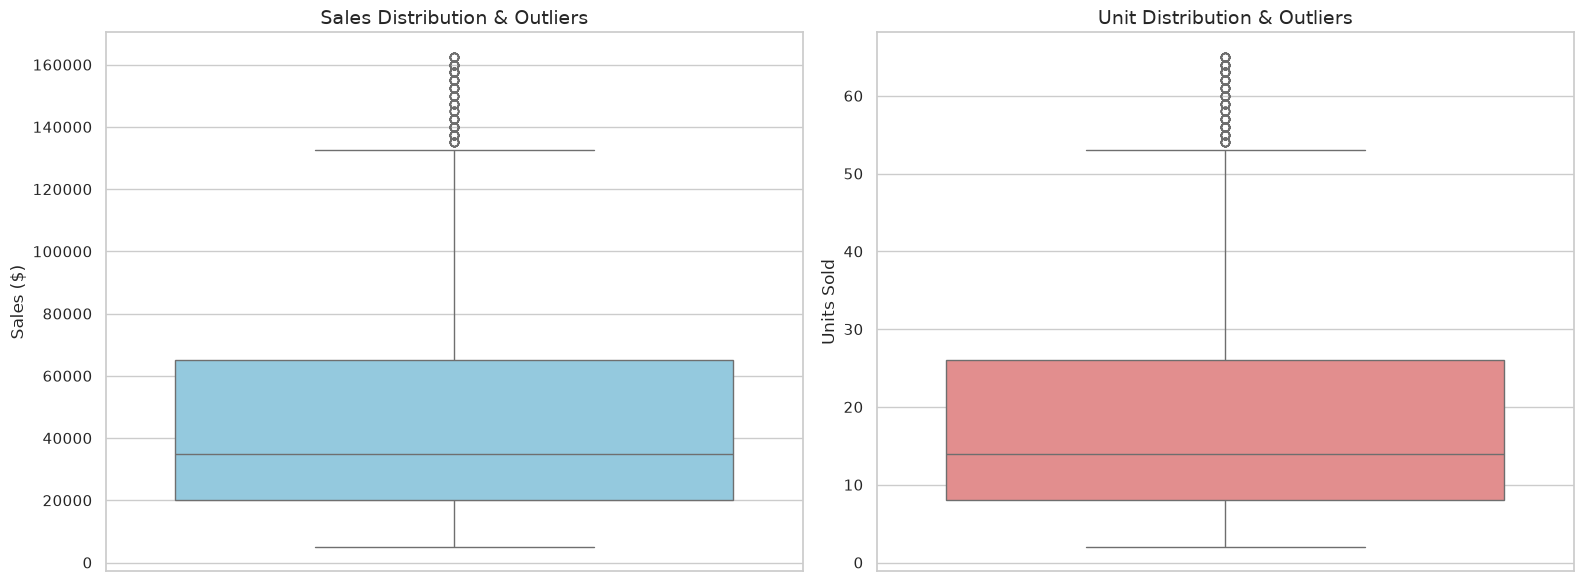

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales Box Plot
sns.boxplot(y='Sales', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Sales Distribution & Outliers', fontsize=14)
axes[0].set_ylabel('Sales ($)', fontsize=12)

# Unit Box Plot
sns.boxplot(y='Unit', data=df, ax=axes[1], color='lightcoral')
axes[1].set_title('Unit Distribution & Outliers', fontsize=14)
axes[1].set_ylabel('Units Sold', fontsize=12)

plt.tight_layout()
plt.show()

### T5.2: State-wise Demographic & Group-wise State Sales

We construct segmented bar charts to compare sales by demographic groups across states, and vice versa.

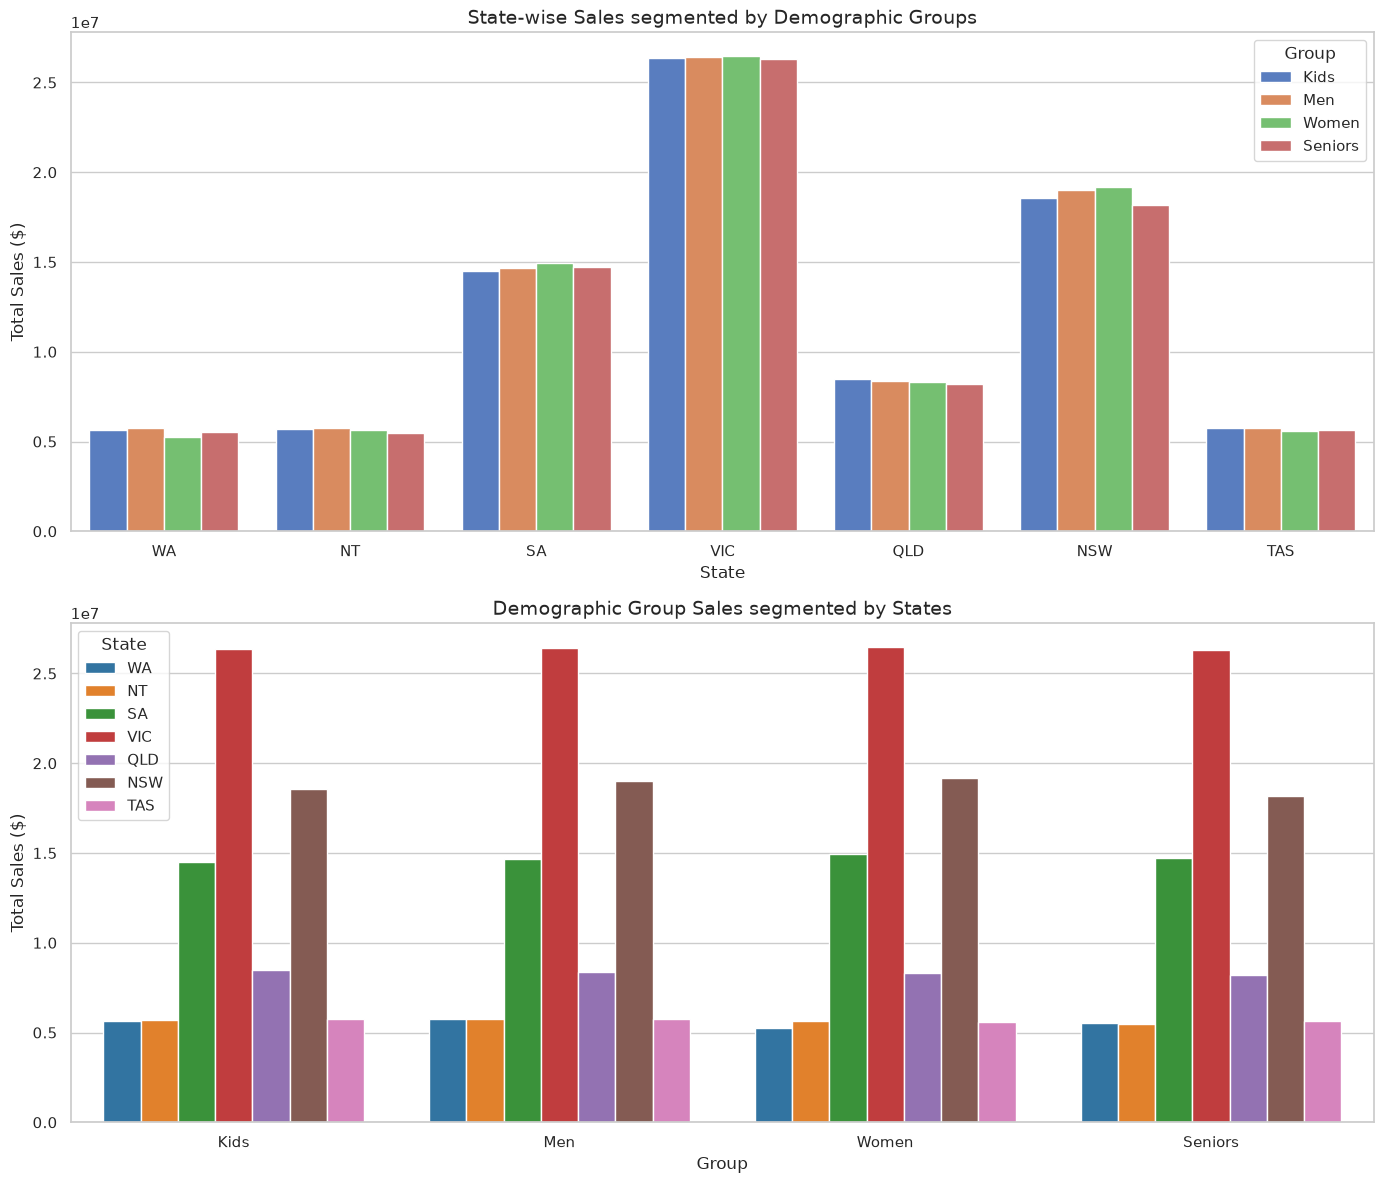

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# State-wise demographic sales
sns.barplot(x='State', y='Sales', hue='Group', data=df, estimator=sum, errorbar=None, ax=axes[0], palette='muted')
axes[0].set_title('State-wise Sales segmented by Demographic Groups', fontsize=14)
axes[0].set_ylabel('Total Sales ($)', fontsize=12)

# Group-wise state sales
sns.barplot(x='Group', y='Sales', hue='State', data=df, estimator=sum, errorbar=None, ax=axes[1], palette='tab10')
axes[1].set_title('Demographic Group Sales segmented by States', fontsize=14)
axes[1].set_ylabel('Total Sales ($)', fontsize=12)

plt.tight_layout()
plt.show()

### T5.3: Time-of-the-Day Analysis (Peak and Off-Peak Periods)

We analyze sales performance by time-of-day (Morning, Afternoon, Evening) to help S&M teams optimize promotional campaigns.

/tmp/ipykernel_223646/2508645122.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')


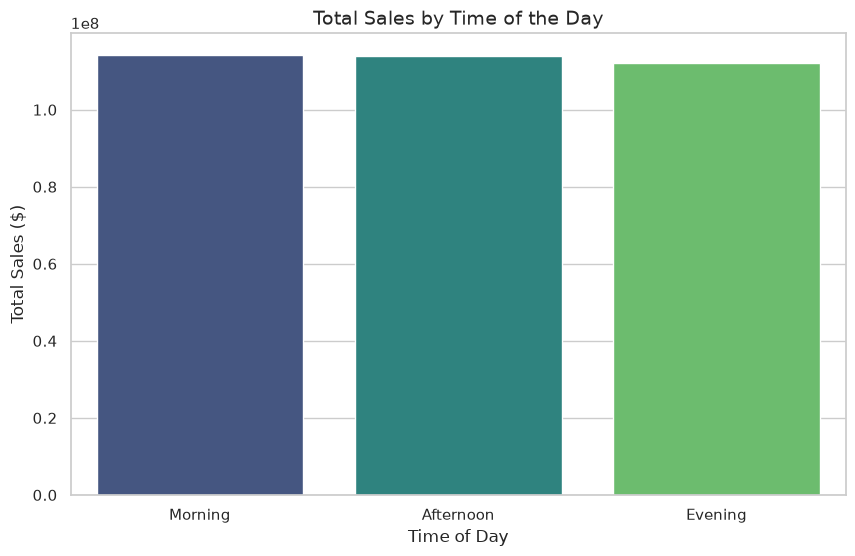

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Time', y='Sales', data=df, estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Sales by Time of the Day', fontsize=14)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xlabel('Time of Day', fontsize=12)
plt.show()

### T5.4: Frequency Distribution Curves (Histograms with KDE)

We use Seaborn distribution plots (`histplot` with KDE line) to visualize the density of sales and units sold.

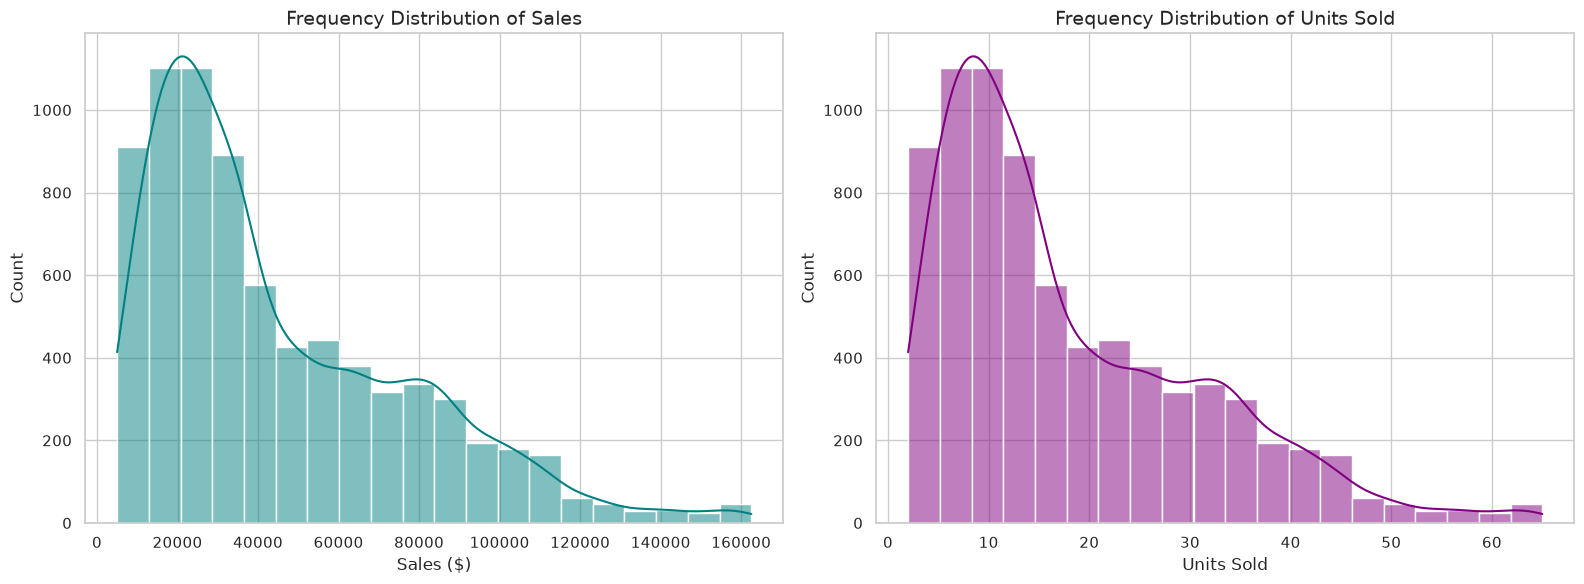

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales Distribution Plot
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Frequency Distribution of Sales', fontsize=14)
axes[0].set_xlabel('Sales ($)', fontsize=12)

# Unit Distribution Plot
sns.histplot(df['Unit'], kde=True, ax=axes[1], color='purple', bins=20)
axes[1].set_title('Frequency Distribution of Units Sold', fontsize=14)
axes[1].set_xlabel('Units Sold', fontsize=12)

plt.tight_layout()
plt.show()

## Phase 6: Insights & Business Recommendations

Based on the results of our data wrangling, descriptive statistics, and Seaborn dashboarding, here are the key insights and recommended business decisions for AAL's CEO:

### 1. Key Insights
*   **Top Revenue States**: **Victoria (VIC)** is the clear market leader, generating **$105.56M** (approx. 31% of total sales), followed by **New South Wales (NSW)** at **$74.97M**.
*   **Lower Revenue States**: **Western Australia (WA)** ($22.15M), **Northern Territory (NT)** ($22.58M), and **Tasmania (TAS)** ($22.76M) generate the lowest sales revenues.
*   **Demographic Consistency**: Revenue across all demographic groups is extremely balanced. **Men** generate the most ($85.75M), while **Seniors** generate the least ($84.03M) - a difference of less than 2%.
*   **Peak Sales Period**: **Morning** ($114.2M) and **Afternoon** ($114.0M) are peak sales hours, whereas **Evening** ($112.0M) is slightly off-peak.

### 2. Strategic S&M Recommendations
1.  **Investment Expansion**: Focus retail expansion and premium stock in **VIC** and **NSW** to capitalize on high demand.
2.  **Targeted Campaigns for Lower-Revenue States**: Formulate promotional programs for **WA, NT, and TAS**. For instance, launch state-specific shipping discounts or localized seasonal clothing bundles to drive market share.
3.  **Time-of-Day Engagement**: Launch hyper-personalized app notifications or Next Best Offers (NBO) during the morning (9 AM - 11 AM) and afternoon (1 PM - 3 PM) to match peak buying behavior.
4.  **Demographic Focus**: Run targeted family-centric discount promotions for **Kids** and **Seniors** during off-peak seasons, as these groups are slightly behind in terms of sales.